[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muhammad-zainal-muttaqin/NulisBuku/blob/main/website/notebooks/ch15.ipynb)

Notebook Bab 15 ini punya dua bagian. Bagian **Demo** tinggal Anda jalankan lalu amati keluarannya; bagian **Mini Project** berisi soal dan data yang Anda kerjakan sendiri.

Demo tidak memperkenalkan data teks/citra/audio baru. Ia membaca ringkasan terverifikasi dari Bab 11-12, lalu memakai subset UCI Covertype 50k untuk membandingkan model tabular pada skala yang lebih besar.


## Persiapan


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')


from pathlib import Path
import json
import urllib.request
import urllib.parse

DATA_BASE_URL = 'https://raw.githubusercontent.com/muhammad-zainal-muttaqin/NulisBuku/main/website/notebooks/data/section1'


def section_data_dir(name):
    """Folder data Bagian 1: pakai salinan lokal bila ada; jika tidak (mis. di
    Google Colab), unduh berkas dari repo GitHub sesuai manifest."""
    for base in (Path('data/section1'), Path('../data/section1')):
        if (base / name).exists():
            return base / name
    cache = Path('_nb_data') / name
    if not (cache / 'manifest.json').exists():
        cache.mkdir(parents=True, exist_ok=True)
        base_url = DATA_BASE_URL + '/' + name
        manifest = json.loads(urllib.request.urlopen(base_url + '/manifest.json').read().decode('utf-8'))
        for rel in manifest:
            dest = cache / rel
            dest.parent.mkdir(parents=True, exist_ok=True)
            if not dest.exists():
                url = base_url + '/' + '/'.join(urllib.parse.quote(seg) for seg in rel.split('/'))
                urllib.request.urlretrieve(url, dest)
        (cache / 'manifest.json').write_text(json.dumps(manifest), encoding='utf-8')
    return cache


## Section 1 - Demo: Reuse Embedding dan Skala Tabular


## Reuse dari Bab 11-12


Reuse rows: 6 from ['data/section1/ch11_sms_spam', 'data/section1/ch12_fashion_mnist', 'data/section1/ch12_fsdd']
       source modality      representation            metric  score
     SMS Spam     text      char_wb TF-IDF average_precision 0.9858
     SMS Spam     text      char_wb TF-IDF                f1 0.9648
Fashion-MNIST    image                 HOG          accuracy 0.8090
Fashion-MNIST    image PCA pixel embedding          accuracy 0.8300
         FSDD    audio                MFCC          accuracy 0.9500
         FSDD    audio         log-mel PCA          accuracy 0.8933


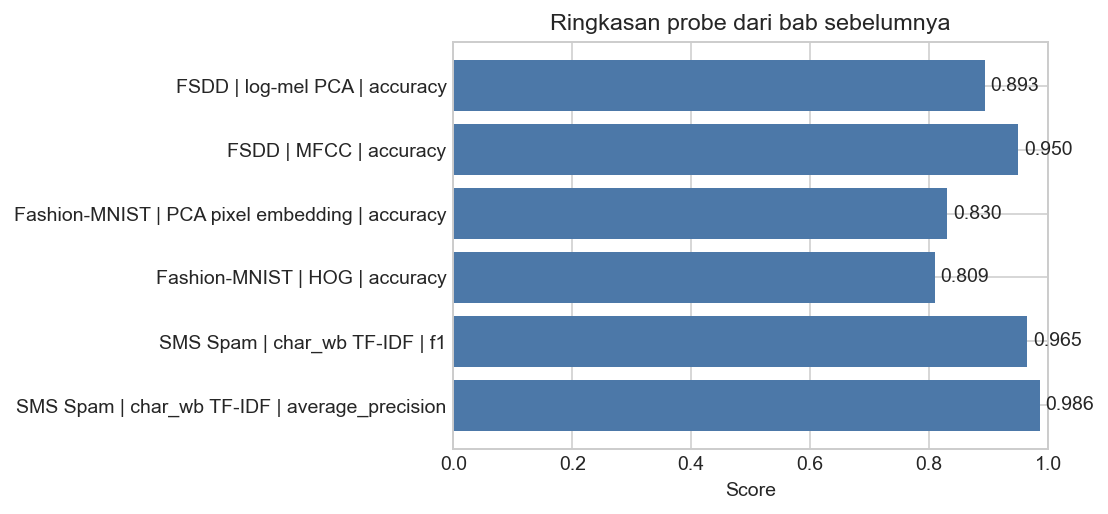

In [2]:
REUSE_DIR = section_data_dir('ch15_sms_fashion_fsdd_reuse')
COV_DIR = section_data_dir('ch15_covtype_50k')
reuse_stats = json.loads((REUSE_DIR / 'verified_stats.json').read_text(encoding='utf-8'))
reuse = pd.read_csv(REUSE_DIR / 'reuse_probe_scores.csv')
print(f"Reuse rows: {reuse_stats['rows']} from {reuse_stats['referenced_snapshots']}")
print(reuse.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

plot_reuse = reuse.copy()
plot_reuse['label'] = plot_reuse['source'] + ' | ' + plot_reuse['representation'] + ' | ' + plot_reuse['metric']
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(plot_reuse['label'], plot_reuse['score'], color='#4c78a8')
ax.set_xlim(0, 1)
ax.set_xlabel('Score')
ax.set_title('Ringkasan probe dari bab sebelumnya')
for i, value in enumerate(plot_reuse['score']):
    ax.text(value + 0.01, i, f'{value:.3f}', va='center')
plt.tight_layout()
plt.show()


## Covertype: tabular besar dengan fitur campuran


Full rows: 581,012; subset rows: 50,000
Features: 54 (10 quantitative + 44 binary wilderness/soil)
Missing values: 0
               model  accuracy  macro_f1  train_rows  test_rows
HistGradientBoosting    0.8440    0.7783       35000      15000
          MLP_scaled    0.7531    0.5307       35000      15000


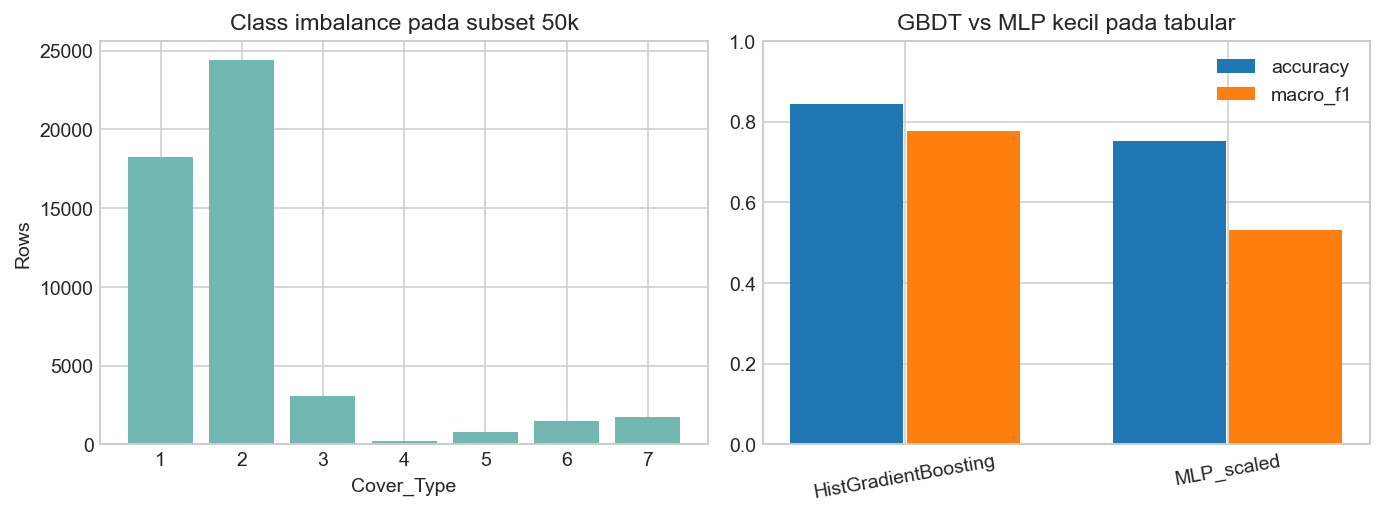

In [3]:
cov_stats = json.loads((COV_DIR / 'verified_stats.json').read_text(encoding='utf-8'))
covtype = pd.read_parquet(COV_DIR / 'covtype_50k.parquet')
class_counts = pd.read_csv(COV_DIR / 'covtype_50k_class_counts.csv')
model_scores = pd.read_csv(COV_DIR / 'covtype_model_scores.csv')

print(f"Full rows: {cov_stats['full_rows']:,}; subset rows: {cov_stats['sample_rows']:,}")
print(f"Features: {cov_stats['features']} ({cov_stats['quantitative_columns']} quantitative + {cov_stats['binary_wilderness_soil_columns']} binary wilderness/soil)")
print(f"Missing values: {cov_stats['missing_values']}")
print(model_scores.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].bar(class_counts['cover_type'].astype(str), class_counts['sample_count'], color='#72b7b2')
axes[0].set_title('Class imbalance pada subset 50k')
axes[0].set_xlabel('Cover_Type')
axes[0].set_ylabel('Rows')
model_plot = model_scores.melt(id_vars='model', value_vars=['accuracy','macro_f1'], var_name='metric', value_name='score')
for metric, group in model_plot.groupby('metric'):
    offset = -0.18 if metric == 'accuracy' else 0.18
    x = np.arange(len(group)) + offset
    axes[1].bar(x, group['score'], width=0.35, label=metric)
axes[1].set_xticks(np.arange(len(model_scores)), model_scores['model'], rotation=10)
axes[1].set_ylim(0, 1)
axes[1].set_title('GBDT vs MLP kecil pada tabular')
axes[1].legend()
plt.tight_layout()
plt.show()


>
> ?? **Amati.** Skor reuse dari Bab 11-12 menunjukkan bahwa embedding atau fitur ringkas bisa sangat berguna pada teks, citra, dan audio. Tetapi Covertype mengingatkan bahwa tabular besar punya aturan main sendiri: pada subset 50k ini, gradient boosting sederhana mengalahkan MLP kecil, terutama pada macro-F1. Ini bukan vonis anti-deep-learning; ini bukti bahwa model tabular tetap perlu diuji dengan ruler lokal.


## Section 2 - Mini Project

## Soal

Gunakan subset Covertype untuk menguji keputusan representasi tabular.

Tugas:

1. Pakai `mini_covtype` dan `feature_cols` dari sel di bawah.
2. Bandingkan model yang memakai semua fitur dengan model yang hanya memakai 10 fitur kuantitatif.
3. Laporkan accuracy dan macro-F1, lalu jelaskan apa kontribusi fitur wilderness/soil biner.

**Luaran:** tabel metrik dan 3-4 kalimat analisis.

**Kriteria penilaian:** (a) split stratified; (b) `Cover_Type` tidak masuk fitur; (c) macro-F1 ikut dilaporkan karena kelas tidak seimbang.


In [4]:
# DATA AWAL (jangan diubah)
mini_covtype = covtype.sample(n=12000, random_state=42).reset_index(drop=True)
feature_cols = [c for c in mini_covtype.columns if c != 'Cover_Type']
quantitative_cols = feature_cols[:10]
binary_cols = feature_cols[10:]
print('Mini shape:', mini_covtype.shape)
print('Quantitative:', len(quantitative_cols), '| binary:', len(binary_cols))
mini_covtype[['Elevation','Aspect','Slope','Cover_Type']].head()


Mini shape: (12000, 55)
Quantitative: 10 | binary: 44


,Elevation,Aspect,Slope,Cover_Type
0,3076,115,15,2
1,2786,70,25,2
2,2838,231,12,5
3,3014,350,5,2
4,3254,251,16,1


In [5]:
# Kerjakan di sini.
# Petunjuk: pakai train_test_split(..., stratify=mini_covtype['Cover_Type']); bandingkan semua fitur vs quantitative_cols.
